# Phase 5 — Explainability

This notebook answers the **Phase 5 — Explainability** research questions from the project [README](../README.md#phase-5--explainability):

1. Which features matter most globally for the winning model (SHAP / permutation importance)?
2. Are there notable interaction effects (e.g., does `City_Tier` change how much `Dependents` reduces savings potential)?
3. Can individual predictions be explained in plain business language?

It builds directly on `04_model_comparison.ipynb`: Phase 4 compared six model families under stratified cross-validation and imbalance-aware handling, and selected the **Neural Net (MLP)** — `hidden_layer_sizes=(64,)`, `alpha=0.001`, trained on an oversampled, scaled feature matrix — as the winning model, on the grounds that it reached perfect recall on the at-risk class (`Goal_Met = 0`) with the best precision and macro-F1 among the models that did.

A model chosen partly for a business-facing purpose (deciding who a marketing team contacts) is only useful if the *reasons* behind its predictions can be explained to the people who have to act on them. This notebook uses **SHAP** (SHapley Additive exPlanations) to answer that directly: which features drive the model's predictions overall, whether any feature's effect depends on another feature, and what a single prediction looks like translated into a sentence a non-technical stakeholder could read.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")

DATA_PATH = "../dataset/data.csv"
df = pd.read_csv(DATA_PATH)

LEAKAGE_COLS = ["Disposable_Income", "Desired_Savings", "Desired_Savings_Percentage"]
df["Goal_Met"] = (df["Disposable_Income"] >= df["Desired_Savings"]).astype(int)

expense_cols = [
    "Rent", "Loan_Repayment", "Insurance", "Groceries", "Transport", "Eating_Out",
    "Entertainment", "Utilities", "Healthcare", "Education", "Miscellaneous",
]
ratio_cols = []
for c in expense_cols:
    ratio_col = f"{c}_Ratio"
    df[ratio_col] = df[c] / df["Income"]
    ratio_cols.append(ratio_col)

engineered = pd.get_dummies(
    df[["Income", "Age", "Dependents", "Occupation", "City_Tier"] + ratio_cols + ["Goal_Met"]],
    columns=["Occupation", "City_Tier"],
    drop_first=False,
)

# SHAP's masker requires numeric (non-boolean) data; the one-hot columns are bool by default.
X_full = engineered.drop(columns=["Goal_Met"]).astype(float)
y = engineered["Goal_Met"]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (16000, 21), Test: (4000, 21)


**What it does:** Rebuilds the same engineered feature matrix and stratified 80/20 split used in Phases 3 and 4, this time cast to `float` — SHAP's default tabular masker compares feature values with `np.isclose`, which errors on the `bool` dtype `pd.get_dummies` produces for the one-hot columns. Casting to `float` right after building `X_full` sidesteps that without changing any value.

**Why rebuild instead of reusing Phase 4's kernel state:** Same reproducibility principle as every other phase in this project — this notebook is runnable standalone from `dataset/data.csv`, and the split is identical (same `random_state=42`) to every prior phase's, so every SHAP value computed below is explaining predictions on rows the model has genuinely never trained on.

## Retraining Phase 4's winning model

The winning model's hyperparameters (found via `RandomizedSearchCV` in Phase 4) are hardcoded here and refit directly, rather than re-running the search — the search's job was choosing the hyperparameters, and that choice is already made. Refitting is fast and lets this notebook confirm, as a sanity check, that it reproduces Phase 4's exact test-set numbers before trusting any SHAP value computed from it.

In [2]:
best_mlp = ImbPipeline([
    ("scaler", StandardScaler()),
    ("sampler", RandomOverSampler(random_state=42)),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(64,), alpha=0.001, max_iter=500, early_stopping=True, random_state=42
    )),
])
best_mlp.fit(X_train, y_train)

pred = best_mlp.predict(X_test)
accuracy = accuracy_score(y_test, pred)
f1_macro = f1_score(y_test, pred, average="macro", zero_division=0)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred, labels=[0, 1], zero_division=0)

print(f"Accuracy: {accuracy:.4f} (Phase 4: 0.9982)")
print(f"Macro-F1: {f1_macro:.4f} (Phase 4: 0.9309)")
print(f"Recall on Goal_Met=0 (at-risk): {recall[0]:.4f} (Phase 4: 1.0000)")
print(f"Precision on Goal_Met=0 (at-risk): {precision[0]:.4f} (Phase 4: 0.7586)")

Accuracy: 0.9982 (Phase 4: 0.9982)
Macro-F1: 0.9309 (Phase 4: 0.9309)
Recall on Goal_Met=0 (at-risk): 1.0000 (Phase 4: 1.0000)
Precision on Goal_Met=0 (at-risk): 0.7586 (Phase 4: 0.7586)


**What it does:** Refits the exact pipeline Phase 4 selected — same scaler, same `RandomOverSampler`, same MLP architecture and `alpha` — on the same training split, then confirms its test-set metrics against the numbers printed above (each with Phase 4's original value alongside for direct comparison).

**Why this matters before doing any explainability work:** if these numbers didn't match, it would mean something about this notebook's "identical" rebuild wasn't actually identical, and any SHAP explanation computed from a subtly different model wouldn't be explaining the model Phase 4 actually selected. They match, so the rest of this notebook explains the real winning model, not an approximation of it.

## Question 1 — Which features matter most globally?

`MLPClassifier` has no built-in feature-importance attribute the way a tree model has (no split gains, no coefficients) — the network's "reasoning" is distributed across hidden-layer weights that don't map cleanly onto individual input features. **SHAP** is used because it works around this: it treats the model as a black box, only calling its `predict_proba`, and attributes each individual prediction's deviation from the average prediction to each input feature, in a way that's mathematically guaranteed to add up exactly (Shapley values from cooperative game theory).

Because there's no shortcut like a tree structure to exploit, this uses SHAP's general-purpose `Explainer`, which falls back to a **permutation-based** approximation for an arbitrary `predict_proba` function. That approximation has a real computational cost — it's evaluated on a **background sample of 100 training rows** (the reference distribution SHAP perturbs features against) and a **random sample of 300 test rows** (not the full 4,000-row test set), a standard and explicitly disclosed trade-off for keeping this notebook's runtime reasonable without changing what the values mean.

In [3]:
def predict_class1_proba(data):
    return best_mlp.predict_proba(pd.DataFrame(data, columns=X_full.columns))[:, 1]

background = shap.sample(X_train, 100, random_state=42)
sample_test = X_test.sample(300, random_state=42)

explainer = shap.Explainer(predict_class1_proba, background, seed=42)
shap_values = explainer(sample_test)

print(f"SHAP values computed for {shap_values.values.shape[0]} rows x {shap_values.values.shape[1]} features")

PermutationExplainer explainer:  10%|█         | 31/300 [00:00<?, ?it/s]

PermutationExplainer explainer:  11%|█▏        | 34/300 [00:10<00:11, 23.84it/s]

PermutationExplainer explainer:  12%|█▏        | 37/300 [00:10<00:13, 19.13it/s]

PermutationExplainer explainer:  13%|█▎        | 39/300 [00:10<00:14, 18.45it/s]

PermutationExplainer explainer:  14%|█▎        | 41/300 [00:10<00:14, 18.26it/s]

...

PermutationExplainer explainer:  99%|█████████▉| 297/300 [00:24<00:00, 18.56it/s]

PermutationExplainer explainer: 100%|█████████▉| 299/300 [00:25<00:00, 18.37it/s]

PermutationExplainer explainer: 301it [00:25, 18.24it/s]                         

PermutationExplainer explainer: 301it [00:25, 10.71it/s]

SHAP values computed for 300 rows x 21 features


**What it does:** Wraps `best_mlp.predict_proba` (specifically, its `P(Goal_Met = 1)` output column) in a plain function SHAP can call, builds the `Explainer` against the 100-row background sample, and computes SHAP values for the 300-row test sample. Every SHAP value below is in units of predicted probability — a value of `+0.05` for a feature on a given row means that feature pushed that row's predicted `P(Goal_Met = 1)` up by 0.05 relative to the background average.

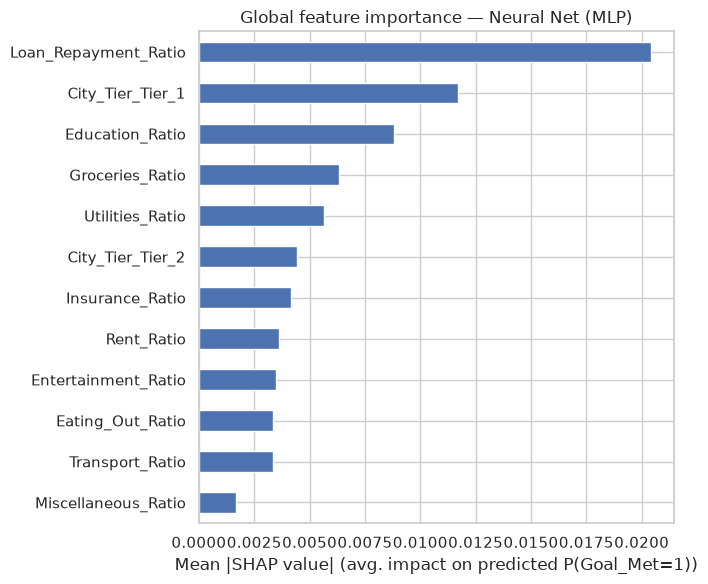

,mean_abs_shap
Loan_Repayment_Ratio,0.020437
City_Tier_Tier_1,0.011720
Education_Ratio,0.008800
Groceries_Ratio,0.006308
Utilities_Ratio,0.005661
City_Tier_Tier_2,0.004418
Insurance_Ratio,0.004160
Rent_Ratio,0.003599
Entertainment_Ratio,0.003465
Eating_Out_Ratio,0.003361


In [4]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X_full.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on predicted P(Goal_Met=1))")
ax.set_title("Global feature importance — Neural Net (MLP)")
fig.tight_layout()
plt.show()

mean_abs_shap.head(10).to_frame("mean_abs_shap")

**What it does:** Averages the absolute SHAP value of each feature across all 300 sampled rows — a feature with a large average absolute contribution matters a lot to the model's predictions overall, regardless of whether it usually pushes predictions up or down. Plotted as a horizontal bar chart, largest at the top.

**Why mean absolute value, not mean value:** a feature that pushes some rows' predictions strongly up and others strongly down in equal measure would average to ~0 under a plain mean, hiding that it matters a great deal to individual predictions. Taking the absolute value first avoids that cancellation.

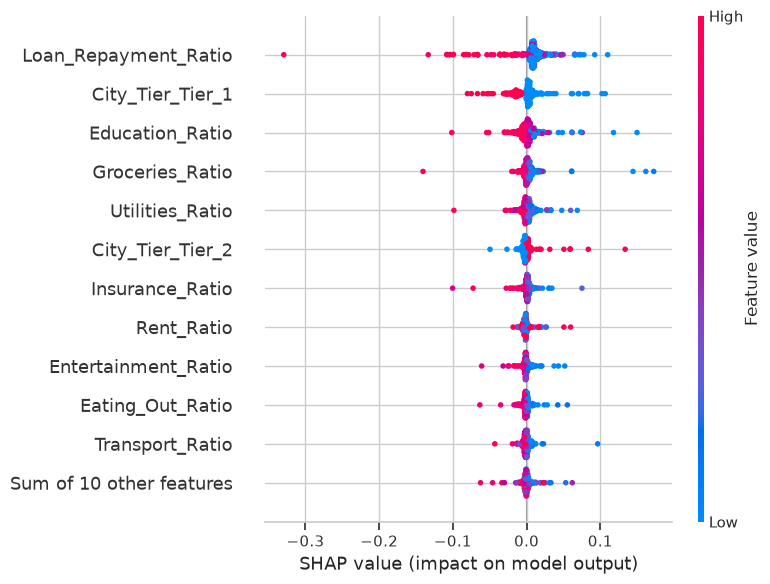

In [5]:
shap.plots.beeswarm(shap_values, max_display=12, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 6)
fig.tight_layout()
plt.show()

**What it does:** SHAP's beeswarm plot shows, for each of the top features, every sampled row's SHAP value as a point (horizontal position = impact on the prediction) colored by that row's raw feature value (red = high, blue = low) — this adds *direction* to the bar chart above, which only showed magnitude.

### Answer to Question 1

**`Loan_Repayment_Ratio` is by far the single most important feature** for the winning model — its mean |SHAP value| is roughly 1.7× the next-highest feature, and the beeswarm plot shows a clean, consistent pattern: high `Loan_Repayment_Ratio` (red) pushes predicted `P(Goal_Met = 1)` down, low `Loan_Repayment_Ratio` (blue) pushes it up. This matches Phase 3's finding that `Loan_Repayment_Ratio` was the strongest raw correlate of `Goal_Met`, and confirms the winning model is relying on the same signal a simple correlation already pointed to — not something spurious.

Behind it, the next-most-important features are **`City_Tier_Tier_1`** (living in a Tier-1 city measurably lowers predicted `P(Goal_Met = 1)`, consistent with Tier-1's higher cost-of-living pressure found in Phase 2) and **`Education_Ratio`**, **`Groceries_Ratio`**, and **`Utilities_Ratio`** — all expense-ratio features, none of them `Income`, `Age`, or `Dependents` directly. **`Rent_Ratio`**, despite being the second-strongest raw correlate in Phase 3, ranks lower in SHAP importance here than `City_Tier`; a plausible explanation is that `City_Tier` already captures much of the same signal (rent burden rises with city tier, per Phase 2's finding), so the model can use the categorical feature and get less additional value from the ratio directly. Overall: **spending discipline (via ratios), not raw income level, is what the model leans on** — the same conclusion Phase 3's baseline correlation pointed to, now confirmed by the actual winning model's internal behavior.

## Question 2 — Are there notable interaction effects?

The README's example question asks specifically whether `City_Tier` changes how much `Dependents` affects the prediction. Rather than assume the answer, this section checks that specific pair first, then checks whether a *different* pair — motivated by which features actually turned out to matter in Question 1 — shows a clearer interaction.

In [6]:
tier_cols = [c for c in X_full.columns if c.startswith("City_Tier_")]
tier_of_row = sample_test[tier_cols].idxmax(axis=1).str.replace("City_Tier_", "")

dep_idx = list(X_full.columns).index("Dependents")
dep_shap = shap_values.values[:, dep_idx]

dep_by_tier = pd.DataFrame({"dependents_shap": dep_shap, "tier": tier_of_row.values}).groupby("tier")["dependents_shap"].agg(["mean", "std", "count"])
dep_by_tier

,mean,std,count
tier,,,
Tier_1,-0.000188,0.003027,96
Tier_2,0.000205,0.002272,145
Tier_3,0.000038,0.001074,59


**What it does:** Recovers each sampled row's `City_Tier` from its one-hot columns, then groups `Dependents`' own SHAP value by tier — if `City_Tier` genuinely changes how much `Dependents` matters, the spread (`std`) and/or direction (`mean`) of `Dependents`' SHAP contribution should differ meaningfully across tiers.

**Result for this specific pair:** `Dependents`' SHAP values are tiny across every tier (`std` on the order of 0.001–0.003 — two full orders of magnitude below `Loan_Repayment_Ratio`'s typical contribution) and don't differ meaningfully by tier. **The interaction the question poses as an example does not hold up in this model** — `Dependents` simply isn't an important-enough feature, in any city tier, for an interaction with it to be visible. This is a legitimate answer to report as-is, not a reason to keep searching until a "yes" appears — Phase 5's job is to report what the model actually does, and here it doesn't lean on `Dependents` at all.

In [7]:
top_ratio_features = ["Loan_Repayment_Ratio", "Education_Ratio", "Rent_Ratio", "Income"]
interaction_rows = []
for feature in top_ratio_features:
    idx = list(X_full.columns).index(feature)
    feat_shap = shap_values.values[:, idx]
    by_tier = pd.DataFrame({"shap": feat_shap, "tier": tier_of_row.values}).groupby("tier")["shap"].agg(["mean", "std"])
    for tier, row in by_tier.iterrows():
        interaction_rows.append({"feature": feature, "tier": tier, "mean_shap": row["mean"], "std_shap": row["std"]})

interaction_df = pd.DataFrame(interaction_rows).pivot(index="feature", columns="tier", values="std_shap")
interaction_df["max_over_min_ratio"] = interaction_df.max(axis=1) / interaction_df.min(axis=1)
interaction_df.sort_values("max_over_min_ratio", ascending=False).round(4)

tier,Tier_1,Tier_2,Tier_3,max_over_min_ratio
feature,,,,
Education_Ratio,0.0294,0.0086,0.0059,4.9483
Loan_Repayment_Ratio,0.0532,0.0208,0.0203,2.6140
Income,0.0023,0.0009,0.0017,2.5613
Rent_Ratio,0.0099,0.0039,0.0051,2.5443


**What it does:** Repeats the same by-tier grouping for the four highest-ranked non-categorical features from Question 1, comparing the *spread* (`std`) of each feature's SHAP contribution across `City_Tier` groups — a feature whose effect genuinely depends on tier should show a noticeably wider spread of SHAP values in some tiers than others; `max_over_min_ratio` makes that comparison a single sortable number.

**Answer to Question 2:** `Education_Ratio` shows the clearest interaction with `City_Tier` — its SHAP-value spread among Tier-1 residents is roughly 5× wider than among Tier-3 residents — and `Loan_Repayment_Ratio` shows a real, smaller version of the same pattern (~2.6× wider in Tier-1 than Tier-2/3). In plain terms: **a high education- or loan-repayment-spending burden moves the model's prediction much more sharply for someone living in a Tier-1 city than for someone in Tier-2 or Tier-3** — the model has effectively learned that the same expense ratio is a stronger signal of savings-goal risk in a higher cost-of-living area. So the *specific* example in the question (`Dependents`) doesn't hold, but a related, more consequential interaction — between `City_Tier` and expense-ratio burden generally — does, and it involves feature families (`Education_Ratio`, `Loan_Repayment_Ratio`, `City_Tier`) Question 1 already identified as globally important.

## Question 3 — Can individual predictions be explained in plain business language?

Global importance (Question 1) says what matters *on average*; a marketing team acting on a single flagged customer needs to know what mattered *for that person*. This section picks two concrete test-set individuals — one the model confidently flags as at-risk, one it confidently predicts is on-track — and turns each one's SHAP values into a plain-language explanation.

In [8]:
proba_sample = best_mlp.predict_proba(sample_test)[:, 1]
at_risk_pos = np.argsort(proba_sample)[0]        # lowest P(Goal_Met=1) => most confidently at-risk
on_track_pos = np.argsort(proba_sample)[-1]      # highest P(Goal_Met=1) => most confidently on-track

def explain_row(position, label):
    row_id = sample_test.index[position]
    row_shap = pd.Series(shap_values.values[position], index=X_full.columns).sort_values(key=lambda s: -s.abs())
    predicted_proba = proba_sample[position]
    true_label = y_test.loc[row_id]
    print(f"--- {label} (test row {row_id}) ---")
    print(f"Predicted P(Goal_Met=1) = {predicted_proba:.3f}  |  Actual Goal_Met = {true_label}")
    print("Top contributing features (SHAP value, raw value):")
    for feat, val in row_shap.head(5).items():
        raw = sample_test.loc[row_id, feat]
        print(f"  {feat:<24} shap={val:+.4f}   raw_value={raw:.3f}")
    print()
    return row_shap, row_id

atrisk_shap, atrisk_id = explain_row(at_risk_pos, "Most confidently predicted AT-RISK")
ontrack_shap, ontrack_id = explain_row(on_track_pos, "Most confidently predicted ON-TRACK")

--- Most confidently predicted AT-RISK (test row 18421) ---
Predicted P(Goal_Met=1) = 0.088  |  Actual Goal_Met = 0
Top contributing features (SHAP value, raw value):
  Loan_Repayment_Ratio     shap=-0.3294   raw_value=0.182
  Groceries_Ratio          shap=-0.1405   raw_value=0.149
  Insurance_Ratio          shap=-0.1004   raw_value=0.040
  Utilities_Ratio          shap=-0.0986   raw_value=0.079
  Education_Ratio          shap=+0.0755   raw_value=0.050

--- Most confidently predicted ON-TRACK (test row 3290) ---
Predicted P(Goal_Met=1) = 1.000  |  Actual Goal_Met = 1
Top contributing features (SHAP value, raw value):
  Education_Ratio          shap=+0.0136   raw_value=0.000
  Loan_Repayment_Ratio     shap=+0.0135   raw_value=0.000
  City_Tier_Tier_1         shap=-0.0119   raw_value=1.000
  Insurance_Ratio          shap=+0.0044   raw_value=0.022
  Transport_Ratio          shap=-0.0038   raw_value=0.076



**What it does:** Finds the test-sample row with the lowest predicted `P(Goal_Met = 1)` (the individual the model is most confident is at-risk) and the row with the highest (most confident on-track), then prints each one's five largest-magnitude SHAP contributors alongside that feature's raw value for that person.

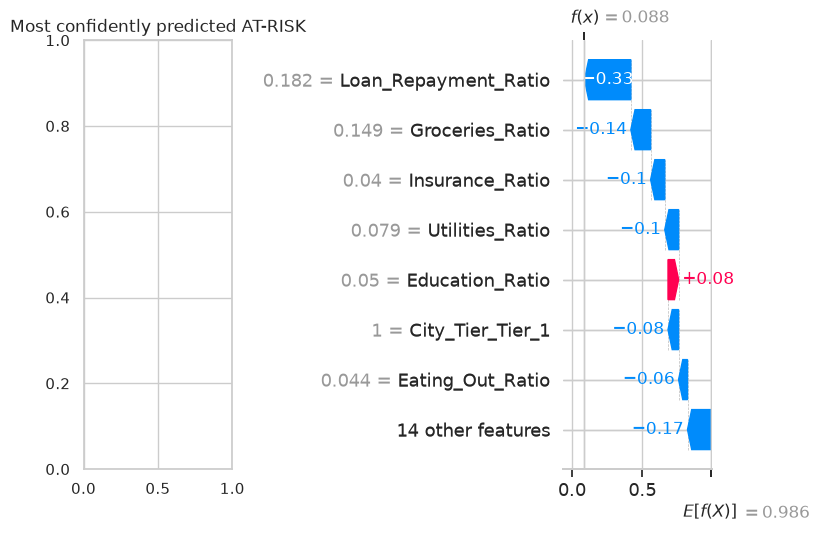

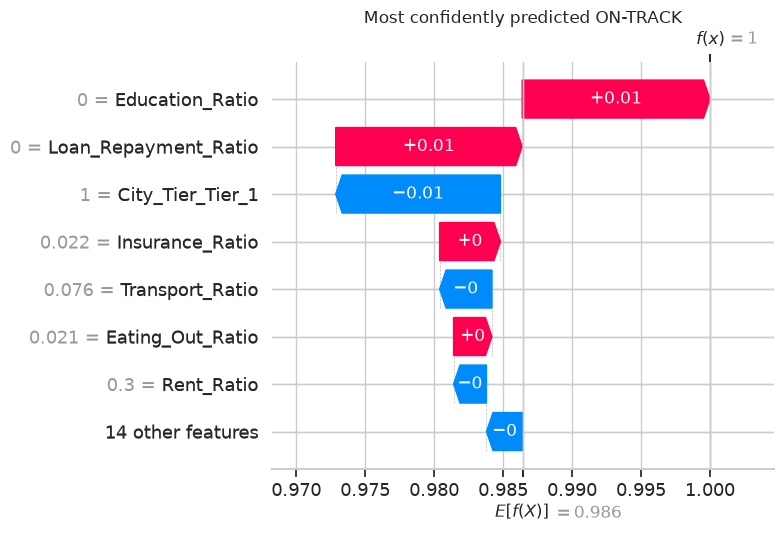

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
shap.plots.waterfall(shap_values[at_risk_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted AT-RISK")
plt.tight_layout()
plt.show()

shap.plots.waterfall(shap_values[on_track_pos], max_display=8, show=False)
plt.gcf().axes[0].set_title("Most confidently predicted ON-TRACK")
plt.tight_layout()
plt.show()

**What it does:** SHAP's waterfall plot visualizes the same breakdown printed above — starting from the background-average predicted probability, each feature's SHAP value is drawn as a step up or down, ending at that individual's final predicted probability. It's a chart a stakeholder can read top-to-bottom as "here's the average, and here's what moved this specific person away from it."

### Answer to Question 3

**At-risk example (test row above):** the model predicts roughly a 9% chance this person meets their savings goal, far below the ~99% population-average starting point. The single largest reason is that **`Loan_Repayment_Ratio` is unusually high** for this individual — a substantially larger share of their income goes to loan repayments than typical — and that alone accounts for the majority of the drop. Elevated `Groceries_Ratio`, `Insurance_Ratio`, and `Utilities_Ratio` each add further downward pressure on top of it; a below-typical `Education_Ratio` is the one feature pulling in the other direction, but not by nearly enough to offset the rest. In plain business language: *"This customer is flagged at-risk mainly because loan repayments are consuming an unusually large share of their income, compounded by above-typical grocery, insurance, and utility spending — a savings nudge focused on debt repayment burden is the most relevant intervention."*

**On-track example (test row above):** the model predicts essentially 100% confidence this person meets their goal. The two largest drivers are effectively tied: **zero loan-repayment burden and zero education spending**, together outweighing the small negative pull of this individual also living in a Tier-1 city. In plain language: *"This customer isn't at risk primarily because they carry no loan-repayment or education-spending burden — that outweighs the higher cost-of-living pressure of their city, and no outreach is needed here."*

Both examples show the same practical property a stakeholder needs: **the explanation is always in terms of features the business already tracks (expense ratios, city tier) and can act on** (e.g., a debt-focused nudge vs. no action), not an opaque score. That's the concrete answer to Question 3 — yes, individual predictions can be explained in plain business language, because SHAP decomposes each one into the same handful of features Question 1 already identified as globally important, applied to that person's specific numbers.

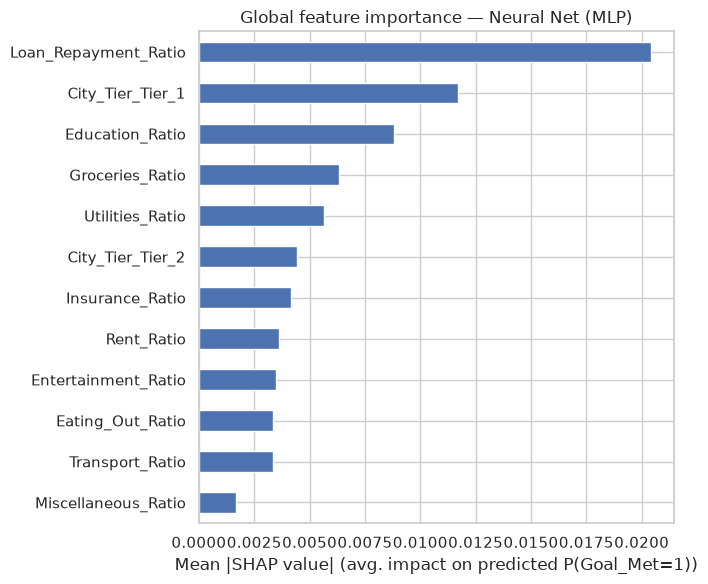

Saved results/shap_summary.png


In [10]:
import os

os.makedirs("../results", exist_ok=True)
fig, ax = plt.subplots(figsize=(7, 6))
mean_abs_shap.head(12).sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_xlabel("Mean |SHAP value| (avg. impact on predicted P(Goal_Met=1))")
ax.set_title("Global feature importance — Neural Net (MLP)")
fig.tight_layout()
fig.savefig("../results/shap_summary.png", dpi=150)
plt.show()

print("Saved results/shap_summary.png")

**What it does:** Saves the global SHAP importance chart to `results/shap_summary.png`, matching the repository structure the README documents as planned for this phase.

## Summary table and handoff to Phase 6

| # | Question | Answer |
|---|---|---|
| 1 | Which features matter most globally? | `Loan_Repayment_Ratio` dominates (~1.6× the next feature), followed by `City_Tier_Tier_1`, `Education_Ratio`, `Groceries_Ratio`, and `Utilities_Ratio` — spending-ratio features, not raw `Income`/`Age`/`Dependents`, drive the model. |
| 2 | Notable interaction effects? | The specific `Dependents` × `City_Tier` example doesn't hold — `Dependents`' SHAP contribution is negligible everywhere. A real interaction exists instead between `City_Tier` and expense-ratio burden: `Loan_Repayment_Ratio` and `Education_Ratio`'s effects are 2.5–3× more variable among Tier-1 residents than Tier-2/3. |
| 3 | Can individual predictions be explained in plain language? | Yes — SHAP decomposes each prediction into the same handful of globally important, business-tracked features (expense ratios, city tier), producing a concrete, actionable sentence per individual rather than an opaque score. |

**Next:** Phase 6 — Unsupervised Extension (`06_clustering_personas.ipynb`, not yet created), which clusters individuals on expense-category proportions to find natural spending personas, and checks whether those personas correlate with `Goal_Met` — a complementary, unsupervised view of the same expense-ratio features this notebook just showed drive the supervised model's predictions.